OBKECTIVE : Analyze sales data to understand profit , sales trends , and buisness performance

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv("train.csv")

# Data Cleaning

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.drop(columns=['Postal Code'],inplace = True)

In [7]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


df.columns

# Q : Total Sales

In [8]:
print(df['Sales'].sum())

2261536.7827000003


TOTAL SALES GENERATED FROM THE DATASET IS 2261536.7827000003

# Q : Which categoty generates most sales?

In [9]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

<Figure size 800x500 with 0 Axes>

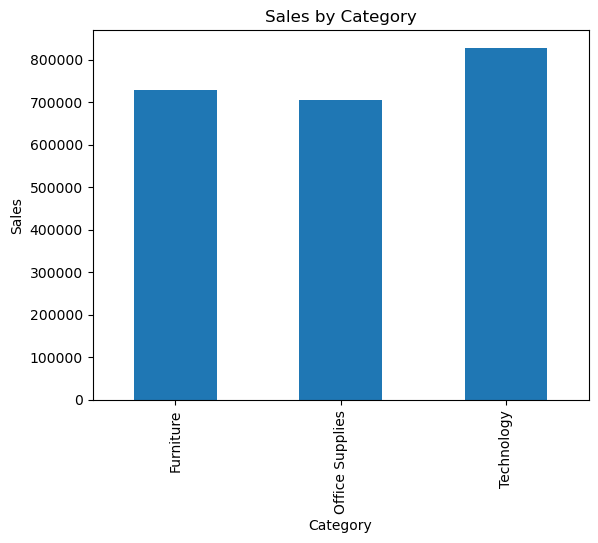

<Figure size 800x500 with 0 Axes>

In [10]:
df.groupby('Category')["Sales"].sum().plot(kind = 'bar')

plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Sales by Category')
plt.figure(figsize=(8,5))

Technology category has the highest sales , followed by Furniture and Office Supplies.

# Q: Which region generates the most sales?

In [11]:
df.groupby('Region')['Sales'].sum().sort_values(ascending = False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

<Figure size 800x500 with 0 Axes>

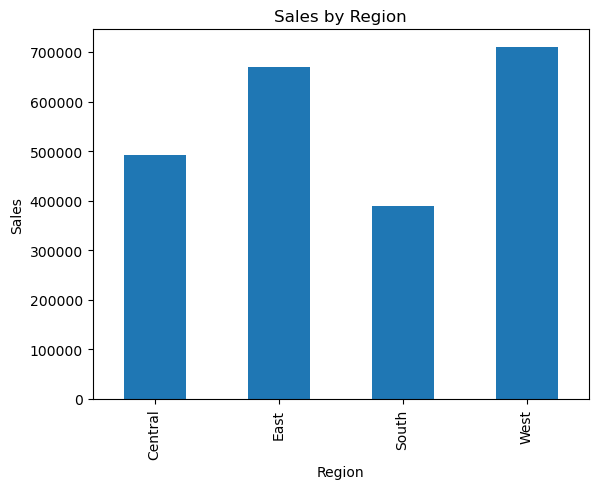

<Figure size 800x500 with 0 Axes>

In [12]:
df.groupby('Region')["Sales"].sum().plot(kind = 'bar')

plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')
plt.figure(figsize=(8,5))

* The West region generates the highest sales, followed by East, Central and South.
* This indicates stronger market demand or better performance in the West region.
* The South region shows comparatively lower sales, suggesting potential growth opportunities.

In [27]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='object')

# Which segment generates highest sales?

In [14]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending = False)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

# Q: Which sub category performs best?

In [15]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False).head(5)

Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64

# Q: Sales trend over time 

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)

df.groupby(df['Order Date'].dt.year)['Sales'].sum()

Order Date
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

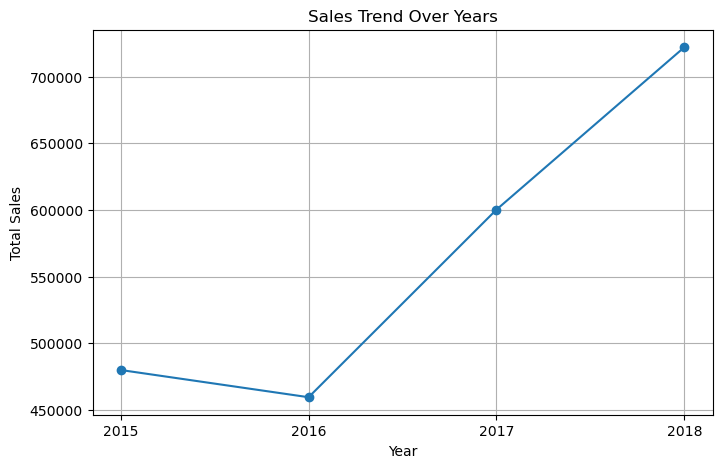

In [17]:
sales_year = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

plt.figure(figsize=(8,5))

plt.plot(sales_year.index, sales_year.values, marker='o')

plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.xticks(sales_year.index)
plt.grid(True)

plt.show()



 Sales show a slight decline from 2015 to 2016, indicating a temporary drop in performance.

 From 2016 onwards, sales increased significantly, showing strong recovery and growth.
 
 The highest sales are recorded in 2018, suggesting consistent business expansion.
 
 This upward trend after 2016 may indicate improved strategies, higher demand, or market growth.

# Q: Top 10 products by sale:

In [18]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

# Q: Category vs Region

In [26]:
pivot =pd.pivot_table(df,values='Sales',index='Region',columns='Category',aggfunc='sum')
print(pivot)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   160317.4622       163590.243  168739.208
East      206461.3880       199940.811  263116.527
South     116531.4800       124424.771  148195.208
West      245348.2455       217466.509  247404.930


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Central'),
  Text(1, 0, 'East'),
  Text(2, 0, 'South'),
  Text(3, 0, 'West')])

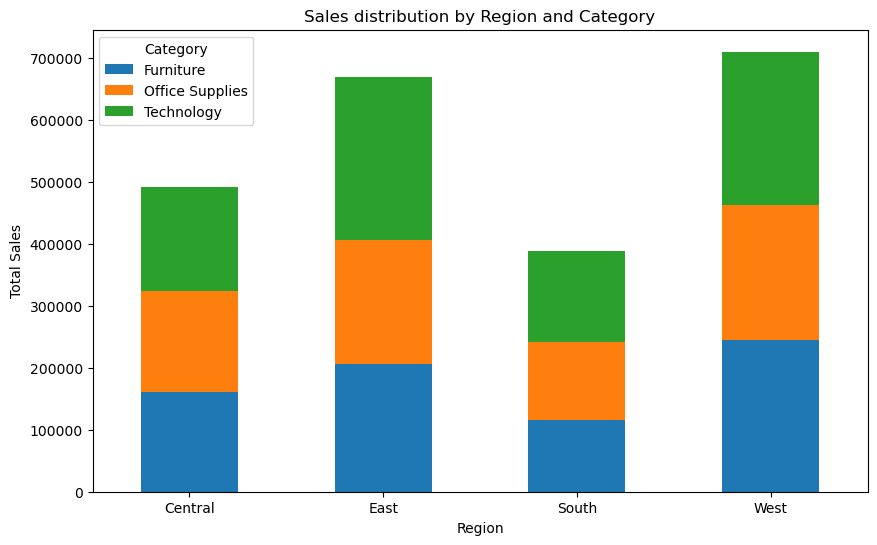

In [25]:
pivot.plot(kind='bar',stacked = True, figsize=(10,6))

plt.title('Sales distribution by Region and Category')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)


West region has highest sales, followed by East.

South region has lowest sales.

Technology category contributes the most across all regions.

# Final Insights :
• West region generates the highest sales.


• Technology category performs the best.


• Consumer segment contributes most revenue.


• Sales have increased over the years.


• Certain products and customers contribute significantly to revenue.

# Limitations:
• Dataset does not contain Profit column.

• Analysis is limited to Sales-based insights.